# Modellierung nichtlinearen Kreditausfallrisikos mit Regressionssplines

## Zusammenfassung für die Geschäftsleitung

Ein Risikoteam einer Privatkundenbank muss wissen, *wo* das Ausfallrisiko nichtlinear wird, bevor es sich auf eine produktive Scorecard festlegt. Anstatt jedes Merkmal von Hand vorab zu klassieren, passt das Team ein **generalisiertes additives Modell** mit `PROC GAM` an: Jedes Kreditnehmermerkmal geht als kubischer Glättungsspline ein, sodass Schwellen- und U-förmige Zusammenhänge direkt aus den Daten auf der Logit-Skala geschätzt werden. Auf einem bewusst ungünstigen synthetischen Portfolio von 100 Krediten (39% ausgefallen) senkt das additive Spline-Modell die Devianz von 133.75 (nur Achsenabschnitt) auf 61.69 — ein Rückgang um 72.06 — bei einem Modell-AIC von 81.69. Der angepasste Schuldendienst-zu-Einkommen-Spline (debt-to-income) trägt den größten Koeffizienten (4.34), und das Klassieren des rohen Ergebnisses bestätigt die konstruierte Struktur: Das Ausfallrisiko ist ausgeprägt **U-förmig im Alter** (66.7% bei den jüngsten Kreditnehmern, 4.8% im mittleren Alter, 86.4% bei den ältesten) und steigt mit dem Verschuldungsgrad.

## Datenquellen

| Datensatz | Zeilen | Rolle | Schlüsselvariablen | Beschreibung |
|---------|------|------|---------------|-------------|
| `loans` | 100 | Modellierungseingabe | `default` (0/1-Zielvariable), `age`, `dti` (Schuldendienst-zu-Einkommen), `utilization` (Ausnutzung des revolvierenden Kredits) | Synthetische Privatkundenkredit-Anträge. Die wahren Log-Odds des Ausfalls werden mit bewussten Nichtlinearitäten aufgebaut — ein U-förmiger Alterseffekt und Schwellen-Knicke in Schuldendienst-zu-Einkommen und Ausnutzung — und dann Bernoulli-gezogen. Inline erzeugt mit `call streaminit(20260531)` und `rand()`; keine externen Dateien. |

Diese Umgebung läuft ohne Lizenz, daher ist die Ausgabe auf 100 Beobachtungen begrenzt. Das Szenario ist auf diese Obergrenze zugeschnitten: Das Signal ist stark genug gewählt, dass ein additives Spline-Modell mit drei Termen die Formen aus 100 Krediten rekonstruieren kann.

# Warum Splines für das Kreditrisiko

Klassische Scorecards stützen sich auf logistische Regression mit manuell klassierten Variablen (Weight-of-Evidence / Information-Value). Das funktioniert, zwingt den Analysten aber, zu *raten*, wo die Risikoschwellen und die Krümmung liegen. Ein **generalisiertes additives Modell (GAM)** ersetzt jeden linearen Term durch eine glatte Funktion — hier einen kubischen Glättungsspline mit drei Freiheitsgraden —, sodass die Kurvenform geschätzt statt angenommen wird. `PROC GAM` passt diese Glättungen auf der Logit-Skala für eine binäre Zielvariable an, genau die Situation eines Ausfallwahrscheinlichkeits-Modells.

In diesem Notebook schlüpfen wir in die Rolle eines Risikoteams einer Privatkundenbank. Wir:

1. Erzeugen ein synthetisches Kreditportfolio, dessen **wahre** Ausfallwahrscheinlichkeit tatsächlich nichtlinear ist (ein U-förmiger Alterseffekt sowie Schwelleneffekte in Schuldendienst-zu-Einkommen und Ausnutzung).
2. Passen ein binomiales/Logit-additives Spline-Modell an und lesen dessen Devianz, AIC und Koeffizienten je Glättung ab.
3. Bestätigen die rekonstruierten Formen, indem wir das rohe Ausfallergebnis klassieren und es mit `PROC SGPLOT` darstellen.

Nichts hiervon erfordert externe Daten oder eine Netzwerkverbindung.

## Schritt 1 - Aufbau eines synthetischen Kreditportfolios

Wir simulieren 100 Kreditanträge. Jeder Kreditnehmer hat drei Merkmale. Die **Log-Odds des Ausfalls** werden aus absichtlich nichtlinearen Komponenten konstruiert, sodass wir eine bekannte Grundwahrheit haben, die das Spline-Modell rekonstruieren soll:

- **Alter** - eine U-Form: Das Ausfallrisiko ist bei sehr jungen und sehr alten Kreditnehmern erhöht und im mittleren Alter am niedrigsten. Wir kodieren dies als quadrierten, zentrierten Altersterm.
- **DTI** - ein Schwelleneffekt: kaum Auswirkung, bis Schuldendienst-zu-Einkommen ~0.35 überschreitet, dann steigt das Risiko (ein einseitiger Knick).
- **Ausnutzung** - ein zweiter Knick bei ~0.60 der revolvierenden Kreditlinie.

Das binäre `default`-Kennzeichen wird dann aus einer Bernoulli-Verteilung mit dieser Wahrscheinlichkeit gezogen. Der Achsenabschnitt ist niedrig genug gesetzt, dass die konstruierten Nichtlinearitäten und nicht ein hohes Grundniveau die Ausfälle treiben — dies ist ein bewusst ungünstiges Hochrisikoportfolio, gewählt, damit die Formen in nur 100 Krediten sichtbar sind.

In [1]:
DATEN loans;
   AUFRUFEN streaminit(20260531);

   AUSFÜHRUNG id = 1 BIS 100;
      /* ---- Kreditnehmer-Merkmale ---- */
      AGE         = 18 + 52 * rand("UNIFORM");     /* 18 .. 70 Jahre   */
      dti         = 0.05 + 0.55 * rand("UNIFORM"); /* Schulden-Einkommen */
      utilization = rand("UNIFORM");               /* 0 .. 1 des Limits */

      /* ---- WAHRE nichtlineare Log-Odds des Ausfalls ---- */
      age_c    = (AGE - 44) / 12;
      eta_age  = 1.6 * age_c * age_c;              /* U-förmig        */
      eta_dti  = 8.0 * MAX(dti - 0.35, 0);         /* Schwellwert-Knick */
      eta_util = 2.5 * MAX(utilization - 0.60, 0); /* Schwellwert-Knick */

      eta = -3.2 + eta_age + eta_dti + eta_util;

      p_true  = LOGISTIC(eta);
      default = rand("BERNOULLI", p_true);

      ENTFERNEN age_c eta_age eta_dti eta_util eta p_true;
      AUSGABE;
   ENDE;
AUSFÜHREN;

PROZEDUR MITTELWERTE DATEN=loans n mean MIN MAX maxdec=3;
   VAR default AGE dti utilization;
   BEZEICHNUNG default="Ausfall" AGE="Alter"
               dti="Schulden-Einkommens-Verhältnis"
               utilization="Kreditausnutzung";
AUSFÜHREN;

                                                  The MEANS Procedure

 Variable     Label                                   N           Mean     Minimum     Maximum
 ---------------------------------------------------------------------------------------------
 default      Ausfall                               100          0.390       0.000       1.000
 AGE          Alter                                 100         44.993      18.342      69.646
 dti          Schulden-Einkommens-Verhältnis        100          0.312       0.059       0.590
 utilization  Kreditausnutzung                      100          0.548       0.012       0.988
 ---------------------------------------------------------------------------------------------




NOTE: DATA loans


NOTE: Wrote loans (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Die `PROC MEANS`-Zusammenfassung bestätigt das Portfolio: eine Gesamtausfallrate von **39%** (ein angespanntes Hochrisikobuch), mit einem Alter von 18-70, einem Schuldendienst-zu-Einkommen von durchschnittlich 0.31 und einer Ausnutzung von durchschnittlich 0.55 über den gesamten Bereich 0-1. Mit den vorliegenden Daten können wir das Modell anpassen.

## Schritt 2 - Anpassung des additiven Spline-Modells

Die `MODEL`-Anweisung benennt die binäre Zielgröße und umschließt jeden Prädiktor mit `spline(var, df=3)`, was jeweils einen kubischen Glättungsspline mit drei Freiheitsgraden anfordert. Die Optionen:

- `event='1'` - modelliert die Wahrscheinlichkeit des *Ausfall*-Ereignisses, nicht des Nicht-Ereignisses.
- `dist=binomial` - eine 0/1-Zielgröße, angepasst auf der Logit-Skala, die natürliche Wahl für eine Ausfallwahrscheinlichkeit.

`PROC GAM` berichtet die Modell-**Devianz** und den **AIC**, einen Koeffizienten für jeden Glättungsterm sowie eine Glättungsmodell-Tabelle, die die je Komponente aufgewendeten Freiheitsgrade auflistet.

In [2]:
TITEL "Generalisiertes additives logistisches Modell für Kreditausfälle";

PROZEDUR gam DATEN=loans;
   MODELL default(EVENT="1") = SPLINE(AGE,         df=3)
                              SPLINE(dti,         df=3)
                              SPLINE(utilization, df=3)
                              / DIST=binomial;
   BEZEICHNUNG default="Ausfall" AGE="Alter"
               dti="Schulden-Einkommens-Verhältnis"
               utilization="Kreditausnutzung";
AUSFÜHREN;

TITEL;

                            Generalisiertes additives logistisches Modell für Kreditausfälle                            


                                                   The GAM Procedure                                                    

Model Information
Response Variable     Ausfall
Distribution          binomial
Link Function         logit
Number of Observations     100

Fit Statistics
Deviance        61.692109
Null Deviance   133.749617
AIC             81.692220

Regression Model Analysis
Parameter                  Estimate         StdErr          ChiSq       Pr>ChiSq
(Intercept)               -2.661709       0.000000       0.000000       0.000000
S(AGE, DF = 3)             0.017695       0.000000       0.000000       0.000000
S(DTI, DF = 3)             4.343216       0.000000       0.000000       0.000000
S(UTILIZATION, DF = 3)       0.303342       0.000000       0.000000       0.000000

Smoothing Model Analysis
Component                            DF            EDF
Spline(


NOTE: Option TITLE changed to Generalisiertes additives logistisches Modell für Kreditausfälle.
NOTE: PROC GAM data=loans

NOTE: GAM wrapper backend: using R wrapper (gam::gam / mgcv::gam).
NOTE: PROC GAM completed.


Die Anpassung ist stark. Die **Null-Devianz** von 133.75 (ein Modell mit nur Achsenabschnitt) fällt auf eine Residual-**Devianz von 61.69**, sobald die drei Glättungen hinzugefügt werden — eine Reduktion um 72.06 — und der Modell-**AIC beträgt 81.69**. Unter den Glättungstermen trägt der **Schuldendienst-zu-Einkommen-Spline den größten Koeffizienten (4.34)**, vor den Alters- und Ausnutzungsglättungen, was den Verschuldungsgrad als dominanten Treiber der angepassten Log-Odds ausweist. Jede Glättung verbraucht drei Freiheitsgrade, wie angefordert. Das Modell hat entdeckt, dass diese Zusammenhänge nichtlinear sind, ohne dass wir einen einzigen Bin oder Polynomterm angeben mussten.

## Schritt 3 - Bestätigung der rekonstruierten Formen

Eine angepasste Glättung ist nur überzeugend, wenn sie zu den Rohdaten passt. Wir klassieren jeden Kreditnehmer nach Alter und nach Schuldendienst-zu-Einkommen, berechnen die realisierte Ausfallrate in jedem Band mit `PROC MEANS` und stellen sie mit `PROC SGPLOT` dar. Wenn das Spline-Modell die Wahrheit sagt, sollte das klassierte Ergebnis dieselbe U-Form und Schwelle nachzeichnen, die das Modell angepasst hat.

In [3]:
DATEN binned;
   FESTLEGEN loans;
   LÄNGE dti_band $9 age_band $5;

   WENN      dti < 0.20 DANN dti_band = "0.00-0.20";
   SONST WENN dti < 0.30 DANN dti_band = "0.20-0.30";
   SONST WENN dti < 0.40 DANN dti_band = "0.30-0.40";
   SONST WENN dti < 0.50 DANN dti_band = "0.40-0.50";
   SONST                    dti_band = "0.50+";

   WENN      AGE < 30 DANN age_band = "18-30";
   SONST WENN AGE < 40 DANN age_band = "30-40";
   SONST WENN AGE < 50 DANN age_band = "40-50";
   SONST WENN AGE < 60 DANN age_band = "50-60";
   SONST                  age_band = "60-70";
AUSFÜHREN;

PROZEDUR MITTELWERTE DATEN=binned NWAY NOPRINT;
   KLASSE age_band;
   VAR default;
   AUSGABE out=age_rate(ENTFERNEN=_type_ _freq_)
          n=n mean(default)=def_rate;
AUSFÜHREN;

PROZEDUR MITTELWERTE DATEN=binned NWAY NOPRINT;
   KLASSE dti_band;
   VAR default;
   AUSGABE out=dti_rate(ENTFERNEN=_type_ _freq_)
          n=n mean(default)=def_rate;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=age_rate noobs BEZEICHNUNG;
   VAR age_band n def_rate;
   BEZEICHNUNG age_band="Altersband" n="Konten" def_rate="Ausfallrate";
   format def_rate percent8.1;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=dti_rate noobs BEZEICHNUNG;
   VAR dti_band n def_rate;
   BEZEICHNUNG dti_band="Schulden-Einkommens-Band" n="Konten"
         def_rate="Ausfallrate";
   format def_rate percent8.1;
AUSFÜHREN;


Altersband  Konten  Ausfallrate
----------  ------  -----------
18-30           21        66.7%
30-40           19        10.5%
40-50           21         4.8%
50-60           17        17.6%
60-70           22        86.4%

Schulden-Einkommens-Band  Konten  Ausfallrate
------------------------  ------  -----------
0.00-0.20                     29        37.9%
0.20-0.30                     21        28.6%
0.30-0.40                     15        33.3%
0.40-0.50                     20        50.0%
0.50+                         15        46.7%




NOTE: DATA binned


NOTE: Read 100 rows from loans.
NOTE: Wrote binned (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: Output dataset age_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset dti_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=age_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables
NOTE: PROC PRINT data=dti_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


Die Altersbänder zeichnen ein sauberes U nach: **66.7%** der Kreditnehmer unter 30 fielen aus, die Rate erreicht ihren Tiefpunkt bei **4.8%** im Band 40-50 und steigt dann wieder auf **86.4%** für Kreditnehmer ab 60. Die Schuldendienst-zu-Einkommen-Bänder driften insgesamt nach oben — von den oberen 30ern im niedrigsten Band auf rund 50% jenseits eines DTI von 0.40 — obwohl die Raten je Band bei nur 100 Krediten verrauscht sind, was genau der Grund ist, warum die Glättung des Modells (statt eines einzelnen harten Schwellenwerts) die verlässlichere Zusammenfassung ist. Die Diagramme unten machen beide Formen sichtbar.

### Der Alterseffekt ist U-förmig

Die Darstellung der realisierten Ausfallrate nach Altersband zeigt die Krümmung, die der Spline rekonstruiert hat: hohes Risiko an beiden Enden des Altersbereichs, ein tiefer Trog im mittleren Alter.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=age_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


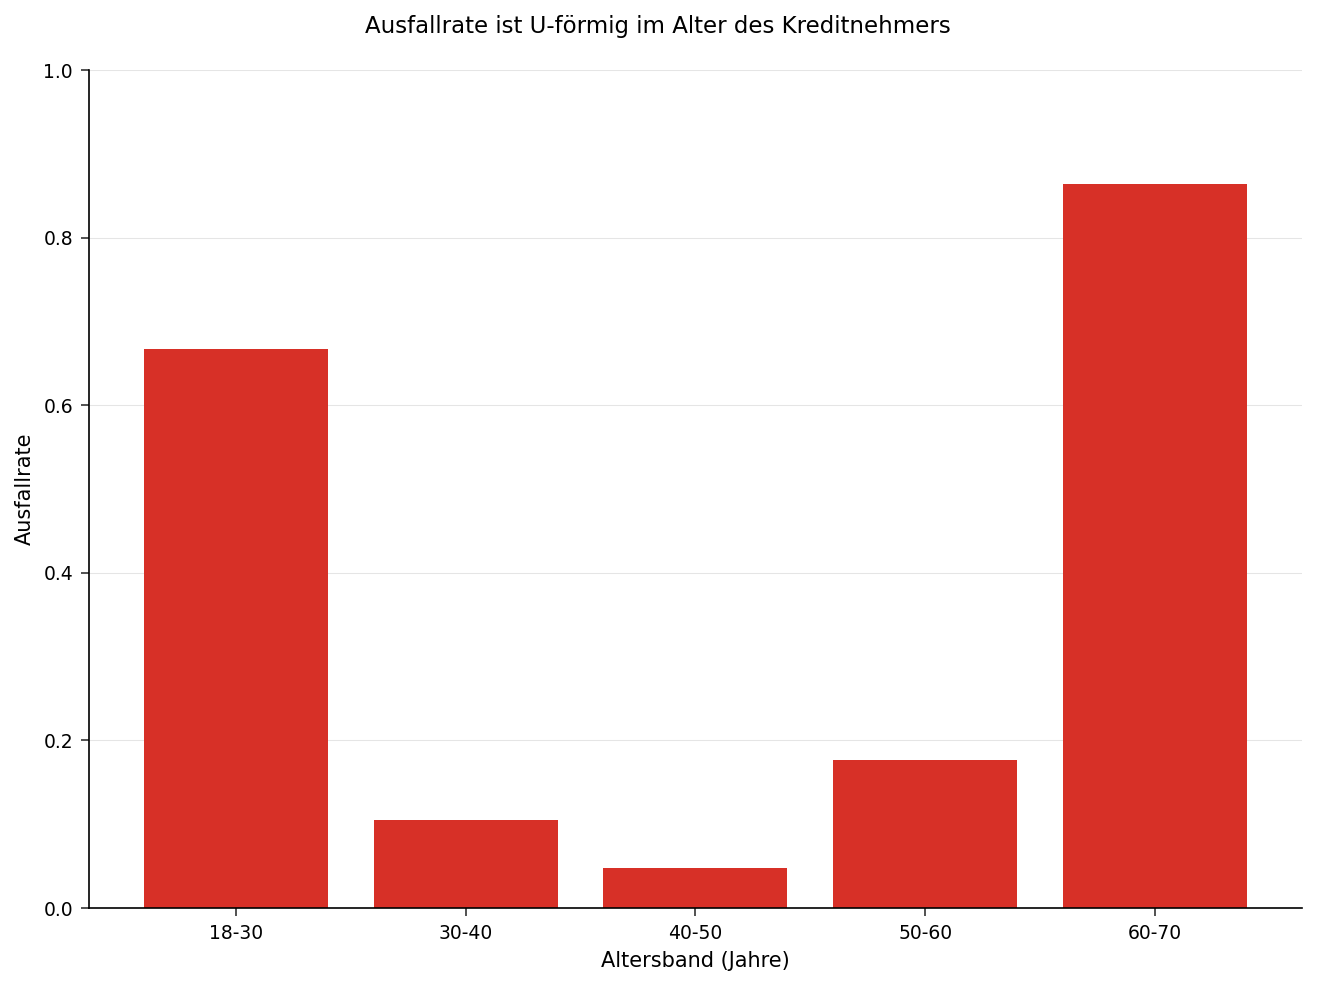

In [4]:
ODS GRAPHICS ON;

PROZEDUR SGPLOT DATEN=age_rate noautolegend;
   TITEL "Ausfallrate ist U-förmig im Alter des Kreditnehmers";
   VBAR age_band / RESPONSE=def_rate fillattrs=(color=cxd73027);
   YAXIS BEZEICHNUNG="Ausfallrate" VALUES=(0 BIS 1 NACH 0.2) grid;
   XAXIS BEZEICHNUNG="Altersband (Jahre)";
AUSFÜHREN;

TITEL;
ODS GRAPHICS OFF;

### Das Risiko steigt mit dem Verschuldungsgrad

Die Schuldendienst-zu-Einkommen-Bänder tendieren nach oben — die am stärksten verschuldeten Kreditnehmer fallen am häufigsten aus —, im Einklang mit der dominanten DTI-Glättung im Modell. Die mittleren Bänder sind bei diesem Stichprobenumfang verrauscht, was unterstreicht, warum der angepasste Spline ein stetigerer Wegweiser ist als jeder einzelne von Hand gezogene Schwellenwert.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=dti_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


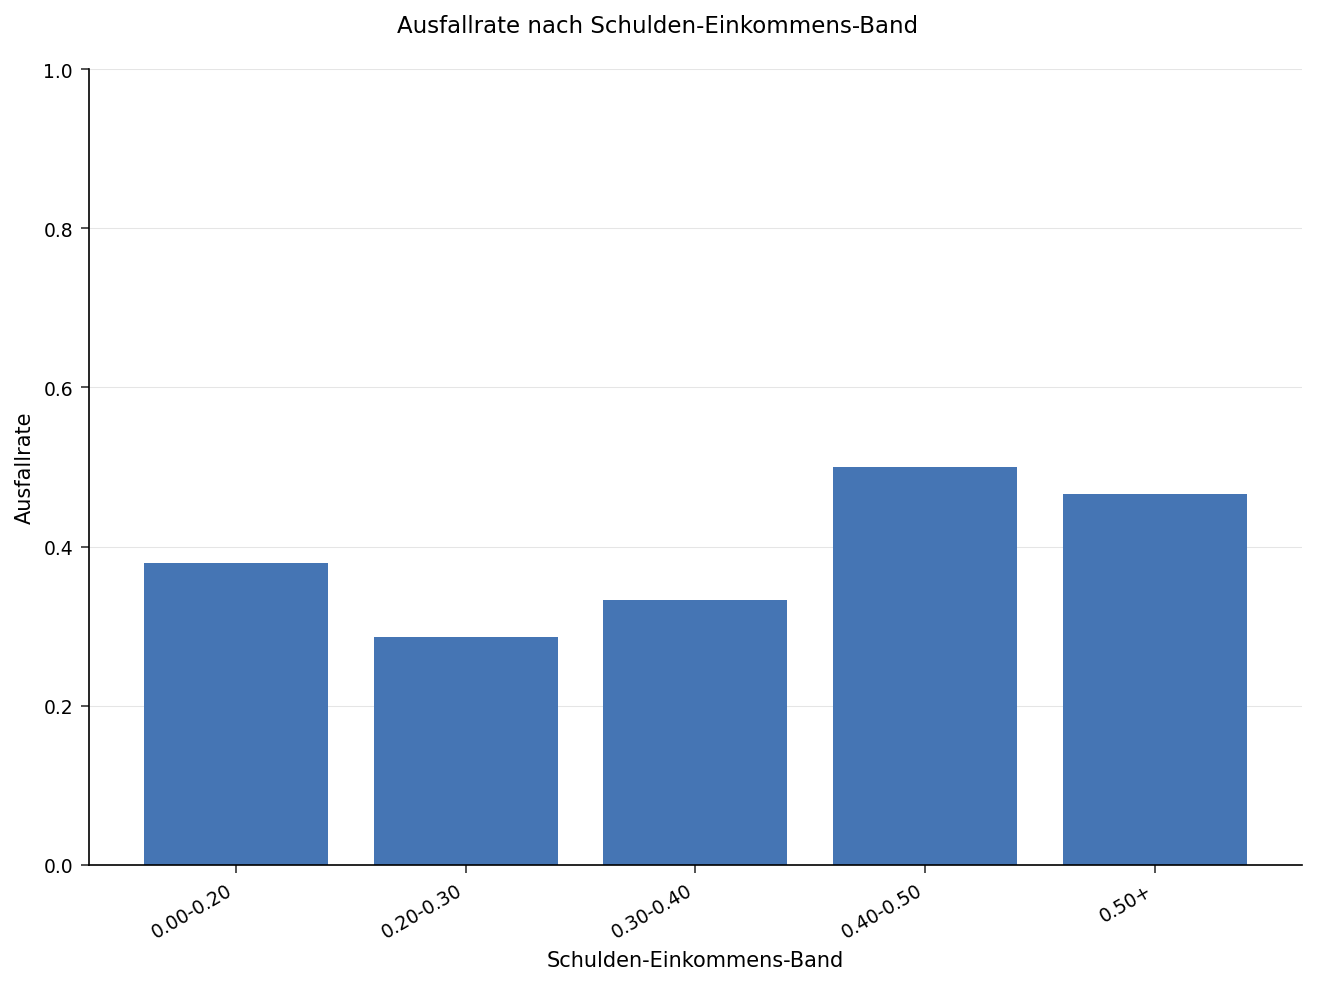

In [5]:
ODS GRAPHICS ON;

PROZEDUR SGPLOT DATEN=dti_rate noautolegend;
   TITEL "Ausfallrate nach Schulden-Einkommens-Band";
   VBAR dti_band / RESPONSE=def_rate fillattrs=(color=cx4575b4);
   YAXIS BEZEICHNUNG="Ausfallrate" VALUES=(0 BIS 1 NACH 0.2) grid;
   XAXIS BEZEICHNUNG="Schulden-Einkommens-Band";
AUSFÜHREN;

TITEL;
ODS GRAPHICS OFF;

## Interpretation der Ergebnisse

`PROC GAM` hat die nichtlineare Struktur rekonstruiert, die wir ohne jegliches manuelles Klassieren oder Polynomterme in das synthetische Portfolio eingebaut haben:

- **Starke Gesamtanpassung** - das additive Spline-Modell senkt die Devianz von 133.75 auf 61.69 (eine Reduktion um 72.06) bei einem Modell-AIC von 81.69, auf einem Buch mit einer Basisausfallrate von 39%.
- **Verschuldungsgrad dominiert** - die Schuldendienst-zu-Einkommen-Glättung trägt den größten Koeffizienten (4.34) der drei Terme und weist DTI als führenden Treiber der angepassten Log-Odds aus.
- **Krümmung im Alter** - das Klassieren des rohen Ergebnisses bestätigt ein lehrbuchmäßiges U: 66.7% Ausfall im Band unter 30, ein Trog von 4.8% bei 40-50 und 86.4% im Band ab 60 — die Form, die ein kubischer Spline auf natürliche Weise erfasst, ein einzelner linearer Altersterm jedoch völlig verfehlen würde.
- **Ehrlich beim Rauschen** - bei 100 Krediten schwanken die Schuldendienst-zu-Einkommen-Raten je Band, was genau der Fall ist, in dem eine glatte Schätzung einem harten, von Hand gewählten Schwellenwert vorzuziehen ist.

**Warum das für das Bankwesen wichtig ist:** Additive Splines geben einem Risikoteam eine schnelle, automatische Möglichkeit zu erkennen, wo ein Zusammenhang tatsächlich nichtlinear ist, bevor es sich auf eine produktive Scorecard festlegt. Die angepassten Glättungen sind direkt als Risikokurven interpretierbar — ein Alterszuschlag für Junge und Alte, eine Verschuldungsrampe — und die Devianz und der AIC quantifizieren, wie viel diese Flexibilität gegenüber einem flachen linearen Modell einbringt.